In [2]:
# Predictive Maintenance — Anomaly Detection with LSTM Classifier
# Dataset: NASA Turbofan Engine Degradation (C-MAPSS, FD001)

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, precision_recall_curve,
                             ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
def find_cmapss_dir():
    base = "/kaggle/input"
    if os.path.isdir(base):
        for root, _, files in os.walk(base):
            if any(f.lower() == "train_fd001.txt" for f in files):
                return root
    return None

DATA_DIR = find_cmapss_dir()

if DATA_DIR is None:
    try:
        import kagglehub
        path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
        for root, _, files in os.walk(path):
            if any(f.lower() == "train_fd001.txt" for f in files):
                DATA_DIR = root
                break
    except Exception as e:
        print("KaggleHub download failed:", e)

assert DATA_DIR is not None, (
    "Could not find train_FD001.txt. Attach the NASA C-MAPSS dataset "
    "via 'Add Data' in the Kaggle sidebar."
)
print("Data directory:", DATA_DIR)
print("Files:", [f for f in os.listdir(DATA_DIR) if f.lower().endswith('.txt')][:10])

Data directory: /kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps
Files: ['RUL_FD002.txt', 'test_FD003.txt', 'readme.txt', 'train_FD003.txt', 'test_FD004.txt', 'train_FD004.txt', 'x.txt', 'test_FD002.txt', 'train_FD001.txt', 'train_FD002.txt']


In [4]:
index_cols   = ["unit", "cycle"]
setting_cols = [f"setting_{i}" for i in range(1, 4)]
sensor_cols  = [f"s_{i}" for i in range(1, 22)]
col_names    = index_cols + setting_cols + sensor_cols

def load_txt(fname):
    fpath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(fpath, sep=r"\s+", header=None)
    df = df.iloc[:, :len(col_names)]
    df.columns = col_names
    return df

train_df = load_txt("train_FD001.txt")
test_df  = load_txt("test_FD001.txt")
rul_df   = pd.read_csv(os.path.join(DATA_DIR, "RUL_FD001.txt"),
                       sep=r"\s+", header=None, names=["RUL"])

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Engines (train):", train_df['unit'].nunique())
train_df.head()

Train shape: (20631, 26)
Test shape : (13096, 26)
Engines (train): 100


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
max_cycle = train_df.groupby("unit")["cycle"].max().rename("max_cycle")
train_df = train_df.merge(max_cycle, on="unit")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df.drop(columns=["max_cycle"], inplace=True)

test_max = test_df.groupby("unit")["cycle"].max().rename("max_cycle").reset_index()
test_max["unit"] = test_max["unit"].values
rul_df["unit"] = np.arange(1, len(rul_df) + 1)
test_max = test_max.merge(rul_df, on="unit")  
test_df = test_df.merge(test_max[["unit", "max_cycle", "RUL"]], on="unit")
test_df["RUL"] = (test_df["max_cycle"] - test_df["cycle"]) + test_df["RUL"]
test_df.drop(columns=["max_cycle"], inplace=True)

print(train_df[["unit", "cycle", "RUL"]].head())
print("Max RUL in train:", train_df["RUL"].max())

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
Max RUL in train: 361


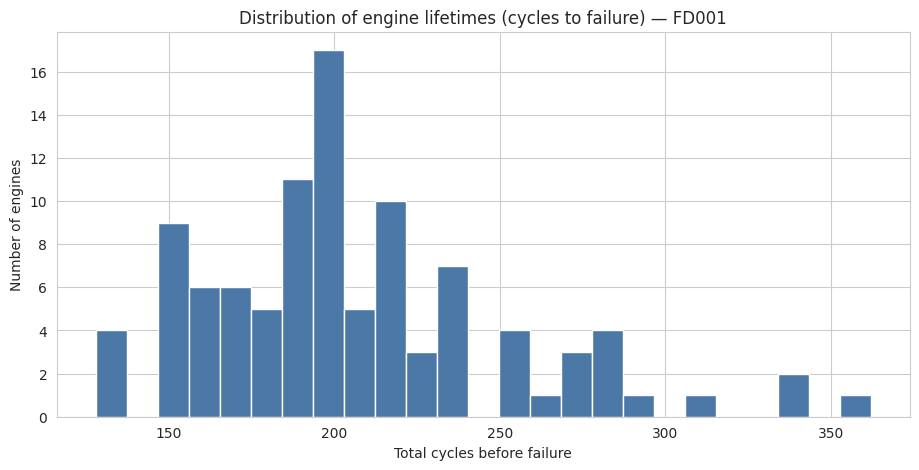

Mean lifetime: 206 cycles | Min: 128 | Max: 362


In [6]:
lifetimes = train_df.groupby("unit")["cycle"].max()
plt.hist(lifetimes, bins=25, color="#4C78A8", edgecolor="white")
plt.title("Distribution of engine lifetimes (cycles to failure) — FD001")
plt.xlabel("Total cycles before failure")
plt.ylabel("Number of engines")
plt.show()

print(f"Mean lifetime: {lifetimes.mean():.0f} cycles | "
      f"Min: {lifetimes.min()} | Max: {lifetimes.max()}")

In [7]:
sensor_std = train_df[sensor_cols].std().sort_values()
print("Sensor standard deviations:\n", sensor_std)

constant_sensors = sensor_std[sensor_std < 1e-6].index.tolist()
print("\nConstant / dropped sensors:", constant_sensors)

useful_sensors = [s for s in sensor_cols if s not in constant_sensors]
print("Useful sensors:", useful_sensors)

Sensor standard deviations:
 s_19    0.000000e+00
s_18    0.000000e+00
s_16    1.556432e-14
s_10    4.660829e-13
s_5     3.394700e-12
s_1     6.537152e-11
s_6     1.388985e-03
s_15    3.750504e-02
s_8     7.098548e-02
s_13    7.191892e-02
s_21    1.082509e-01
s_20    1.807464e-01
s_11    2.670874e-01
s_2     5.000533e-01
s_12    7.375534e-01
s_7     8.850923e-01
s_17    1.548763e+00
s_3     6.131150e+00
s_4     9.000605e+00
s_14    1.907618e+01
s_9     2.208288e+01
dtype: float64

Constant / dropped sensors: ['s_19', 's_18', 's_16', 's_10', 's_5', 's_1']
Useful sensors: ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


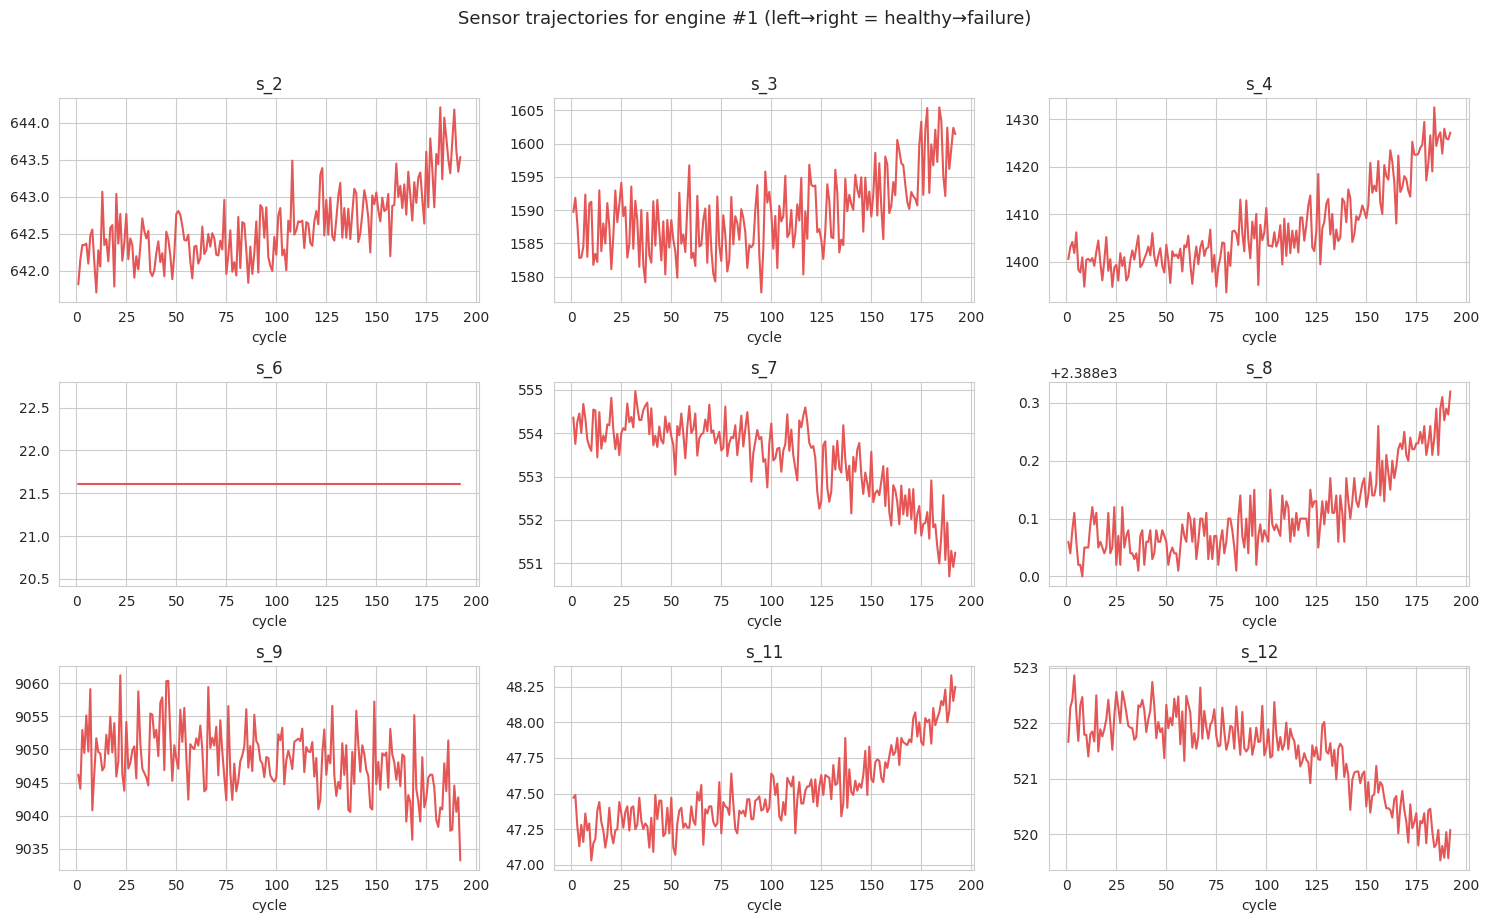

In [8]:
sample_unit = 1
unit_data = train_df[train_df["unit"] == sample_unit]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, s in zip(axes.ravel(), useful_sensors[:9]):
    ax.plot(unit_data["cycle"], unit_data[s], color="#E45756")
    ax.set_title(s)
    ax.set_xlabel("cycle")
fig.suptitle(f"Sensor trajectories for engine #{sample_unit} (left→right = healthy→failure)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

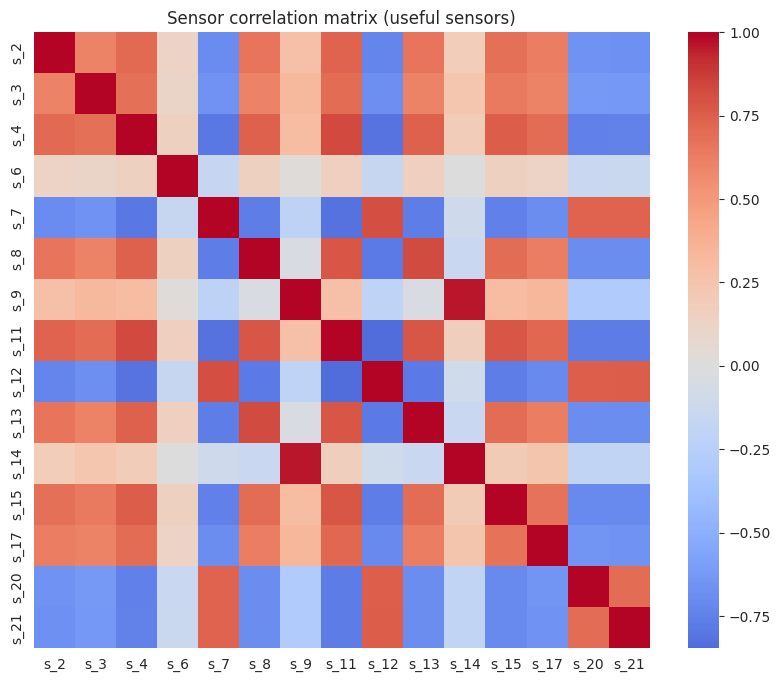

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[useful_sensors].corr(), cmap="coolwarm", center=0,
            annot=False, square=True)
plt.title("Sensor correlation matrix (useful sensors)")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

WINDOW = 30
HEALTHY_RUL = 30
ALERT_HORIZON = 24

healthy_train = train_df[train_df["RUL"] > HEALTHY_RUL]
scaler = StandardScaler()                      
scaler.fit(healthy_train[useful_sensors])

train_scaled = train_df.copy()
test_scaled  = test_df.copy()
train_scaled[useful_sensors] = scaler.transform(train_df[useful_sensors])
test_scaled[useful_sensors]  = scaler.transform(test_df[useful_sensors])

print("Healthy training rows:", len(healthy_train), "/", len(train_df))

Healthy training rows: 17531 / 20631


In [11]:
def make_windows(df, sensors, window):
    X, y, units = [], [], []
    for unit in df["unit"].unique():
        u = df[df["unit"] == unit].sort_values("cycle")
        vals = u[sensors].values
        ruls = u["RUL"].values
        for start in range(len(u) - window + 1):
            end = start + window - 1
            X.append(vals[start:start + window])
            y.append(1 if ruls[end] <= ALERT_HORIZON else 0)
            units.append(unit)
    return np.array(X), np.array(y), np.array(units)

X_all, y_all, units_all = make_windows(train_scaled, useful_sensors, WINDOW)

rng = np.random.default_rng(SEED)
unit_ids = np.unique(units_all)
rng.shuffle(unit_ids)
n_val_units = int(0.2 * len(unit_ids))
val_units = set(unit_ids[:n_val_units].tolist())

val_mask = np.array([u in val_units for u in units_all])
X_tr, y_tr = X_all[~val_mask], y_all[~val_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]

X_test, y_test, _ = make_windows(test_scaled, useful_sensors, WINDOW)

print("X_tr :", X_tr.shape, "| positives:", int(y_tr.sum()), f"({y_tr.mean():.2%})")
print("X_val:", X_val.shape, "| positives:", int(y_val.sum()), f"({y_val.mean():.2%})")
print("X_test:", X_test.shape, "| positives:", int(y_test.sum()), f"({y_test.mean():.2%})")

X_tr : (14459, 30, 15) | positives: 2000 (13.83%)
X_val: (3272, 30, 15) | positives: 500 (15.28%)
X_test: (10196, 30, 15) | positives: 199 (1.95%)


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Dropout

n_features = X_tr.shape[2]

def build_lstm_classifier(window, n_features):
    inp = Input(shape=(window, n_features))
    x = LSTM(64, activation="tanh", return_sequences=True)(inp)   
    x = LSTM(32, activation="tanh", return_sequences=False)(x)    
    x = Dropout(0.2)(x)
    x = Dense(16, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)                    
    model = Model(inp, out, name="LSTM_Classifier")
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss="binary_crossentropy",
                  metrics=["AUC", "Recall", "Precision"])
    return model

clf = build_lstm_classifier(WINDOW, n_features)
clf.summary()

Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
cw = compute_class_weight("balanced", classes=classes, y=y_tr)
class_weight = {0: cw[0], 1: cw[1] * 2.0}  
print("class_weight:", class_weight)

es = EarlyStopping(monitor="val_AUC", mode="max", patience=12,
                   restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                        patience=5, min_lr=1e-5, verbose=1)

history = clf.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[es, rlr],
    verbose=1
)

class_weight: {0: np.float64(0.5802632635042941), 1: np.float64(7.2295)}
Epoch 1/100


I0000 00:00:1780915085.767644   35107 cuda_dnn.cc:529] Loaded cuDNN version 91002


113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - AUC: 0.9692 - Precision: 0.4299 - Recall: 0.9835 - loss: 0.3591 - val_AUC: 0.9927 - val_Precision: 0.7044 - val_Recall: 0.9820 - val_loss: 0.1674 - learning_rate: 0.0010
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9930 - Precision: 0.7177 - Recall: 0.9875 - loss: 0.1313 - val_AUC: 0.9943 - val_Precision: 0.7973 - val_Recall: 0.9520 - val_loss: 0.1080 - learning_rate: 0.0010
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.9947 - Precision: 0.7593 - Recall: 0.9890 - loss: 0.1042 - val_AUC: 0.9949 - val_Precision: 0.8322 - val_Recall: 0.9620 - val_loss: 0.0883 - learning_rate: 0.0010
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9947 - Precision: 0.7626 - Recall: 0.9940 - loss: 0.0986 - val_AUC: 0.9958 - val_Precision: 0.7612 - val_Recall: 0.9880 - val_loss: 0.1104 - learning_rate: 0.0010
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9964 - Precision: 0.7934 - Recall: 0.9925 - l

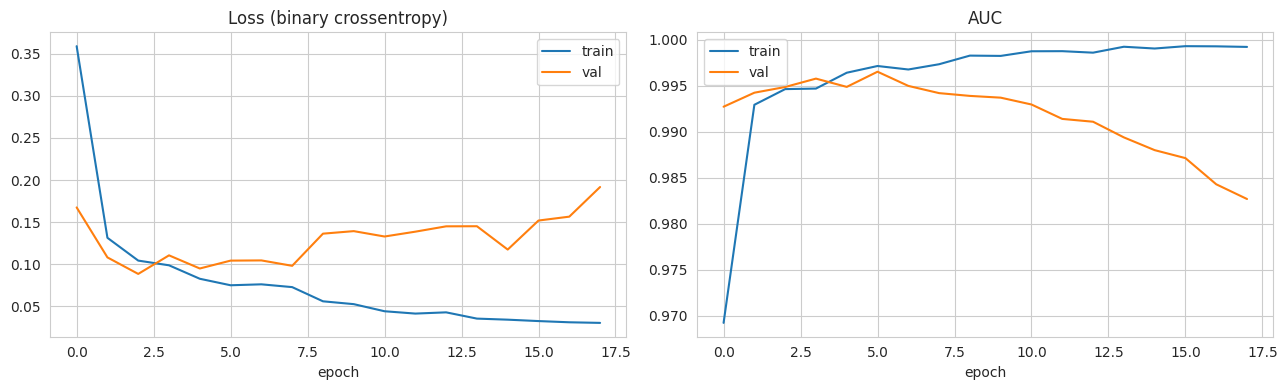

In [14]:
h = history.history
auc_key = next((k for k in h if k.startswith("AUC") and not k.startswith("val")), None)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h["loss"], label="train")
ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("Loss (binary crossentropy)"); ax[0].set_xlabel("epoch"); ax[0].legend()

if auc_key:
    ax[1].plot(h[auc_key], label="train")
    ax[1].plot(h["val_" + auc_key], label="val")
    ax[1].set_title("AUC")
else:
    ax[1].plot(h["loss"], label="train")
    ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title("Loss (fallback)")
ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

Chosen threshold (val): 0.520 (val recall=0.998, val FPR=0.050)


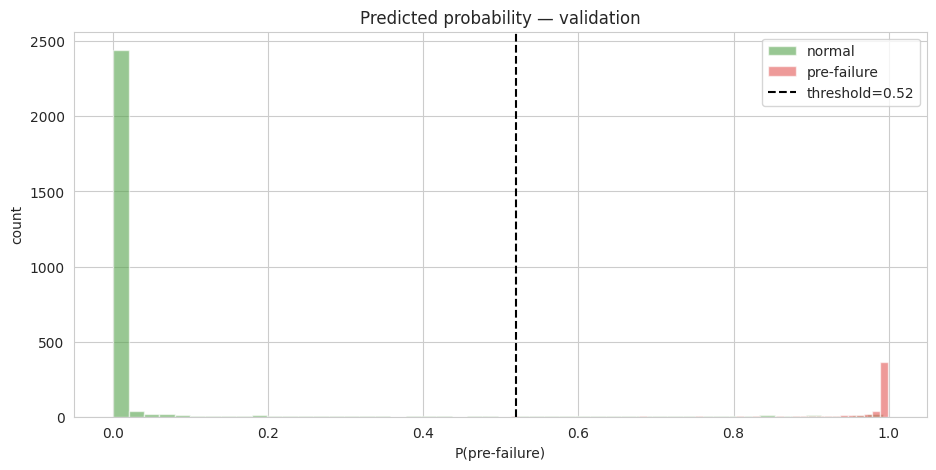

In [15]:
val_proba = clf.predict(X_val, verbose=0).ravel()
test_proba = clf.predict(X_test, verbose=0).ravel()

best = None
for thr in np.linspace(0.01, 0.99, 197):
    pred = (val_proba > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0
    if fpr < 0.05 and (best is None or rec > best[1]):
        best = (thr, rec, fpr)

THRESHOLD = best[0] if best else 0.5
print(f"Chosen threshold (val): {THRESHOLD:.3f} "
      f"(val recall={best[1]:.3f}, val FPR={best[2]:.3f})"
      if best else "No threshold met FPR<5% on val; using 0.5")

plt.hist(val_proba[y_val == 0], bins=50, alpha=0.6, label="normal", color="#54A24B")
plt.hist(val_proba[y_val == 1], bins=50, alpha=0.6, label="pre-failure", color="#E45756")
plt.axvline(THRESHOLD, color="black", ls="--", label=f"threshold={THRESHOLD:.2f}")
plt.title("Predicted probability — validation"); plt.xlabel("P(pre-failure)")
plt.ylabel("count"); plt.legend(); plt.show()

In [18]:
_, _, units_test = make_windows(test_scaled, useful_sensors, WINDOW)
y_pred = (test_proba > THRESHOLD).astype(int)

precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
fpr = fp / (fp + tn) if (fp + tn) else 0

print("================ KPI REPORT (window-level) ================")
print(f"Recall: {recall:.3f}  | target >= 0.85  -> {'PASS' if recall >= 0.85 else 'FAIL'}")
print(f"FPR:    {fpr:.3f}  | target <  0.05  -> {'PASS' if fpr < 0.05 else 'FAIL'}")
print(f"Precision: {precision:.3f}")
print(f"F1: {f1:.3f}")
print("===========================================================")


eng_tp = eng_fn = eng_fp_units = eng_tn_units = 0
for u in np.unique(units_test):
    idx = np.where(units_test == u)[0]
    has_true = y_test[idx].max() == 1        
    has_alert = y_pred[idx].max() == 1         
    if has_true:
        if has_alert: eng_tp += 1
        else:         eng_fn += 1
    else:
        if has_alert: eng_fp_units += 1
        else:         eng_tn_units += 1

eng_recall = eng_tp / (eng_tp + eng_fn) if (eng_tp + eng_fn) else 0
eng_fp_rate = eng_fp_units / (eng_fp_units + eng_tn_units) if (eng_fp_units + eng_tn_units) else 0

print("\n================ KPI REPORT (engine-level) ================")
print(f"Engines caught (recall): {eng_recall:.3f} ({eng_tp}/{eng_tp + eng_fn})"
      f"  | target >= 0.85 -> {'PASS' if eng_recall >= 0.85 else 'FAIL'}")
print(f"False-alarm engines:     {eng_fp_rate:.3f} ({eng_fp_units}/{eng_fp_units + eng_tn_units})")
print("===========================================================")

================ KPI REPORT (window-level) ================
Recall: 0.889  | target >= 0.85  -> PASS
FPR:    0.015  | target <  0.05  -> PASS
Precision: 0.538
F1: 0.670

================ KPI REPORT (engine-level) ================
Engines caught (recall): 1.000 (19/19)  | target >= 0.85 -> PASS
False-alarm engines:     0.049 (4/81)


In [ ]:

import shap
print("SHAP version:", shap.__version__)

rng_shap = np.random.default_rng(SEED)
bg_idx = rng_shap.choice(len(X_tr), size=min(100, len(X_tr)), replace=False)
background = X_tr[bg_idx]


expl_idx = rng_shap.choice(len(X_test), size=min(300, len(X_test)), replace=False)
X_explain = X_test[expl_idx]

explainer = shap.GradientExplainer(clf, background)
shap_values = explainer.shap_values(X_explain)


sv = shap_values[0] if isinstance(shap_values, list) else shap_values
sv = np.array(sv)

if sv.ndim == 4:
    sv = sv[..., 0]
print("SHAP values shape:", sv.shape)

SHAP version: 0.51.0


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6
Received: inputs=['Tensor(shape=(300, 30, 15))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6
Received: inputs=['Tensor(shape=(50, 30, 15))']
  warnings.warn(msg)


SHAP values shape: (300, 30, 15)


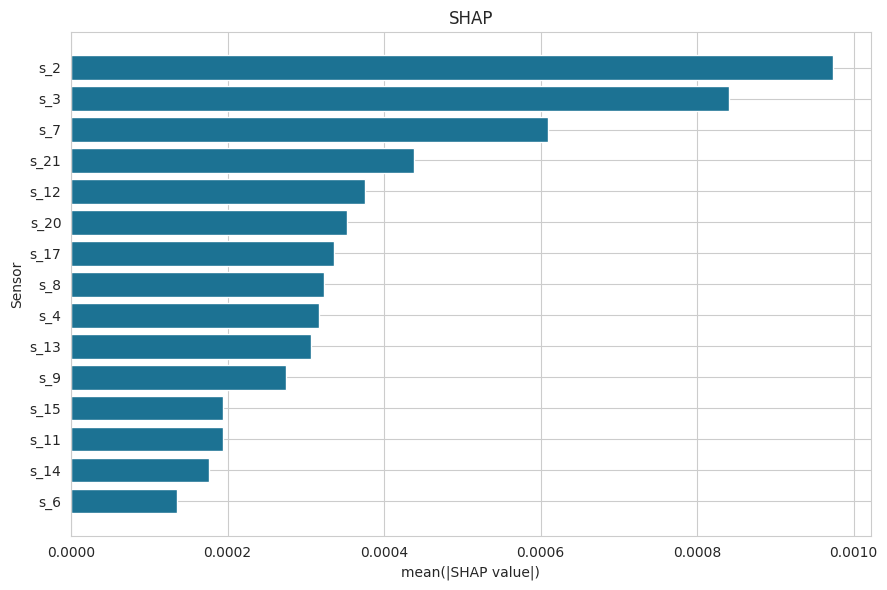

Тop-5 sensors
s_2     0.000973
s_3     0.000840
s_7     0.000609
s_21    0.000438
s_12    0.000376


In [ ]:

mean_abs_shap = np.abs(sv).mean(axis=(0, 1))  
importance = (pd.Series(mean_abs_shap, index=useful_sensors)
              .sort_values(ascending=True))

plt.figure(figsize=(9, 6))
plt.barh(importance.index, importance.values, color="#1C7293")
plt.xlabel("mean(|SHAP value|)")
plt.ylabel("Sensor")
plt.title("SHAP")
plt.tight_layout()
plt.show()

print("Тop-5 sensors")
print(importance.sort_values(ascending=False).head(5).to_string())

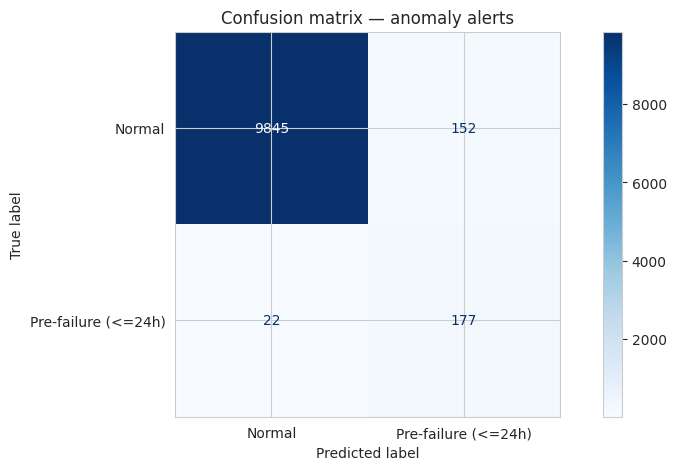

In [19]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Pre-failure (<=24h)"]).plot(
    cmap="Blues", values_format="d")
plt.title("Confusion matrix — anomaly alerts")
plt.show()

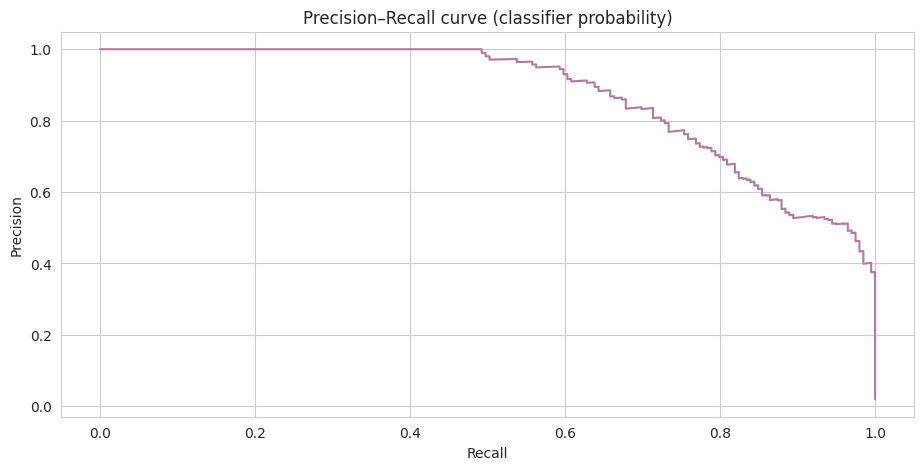

In [20]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_proba)
plt.plot(rec_curve, prec_curve, color="#B279A2")
plt.title("Precision–Recall curve (classifier probability)")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.show()

In [21]:
print(f"{'thr':>6} {'recall':>8} {'FPR':>8} {'prec':>8}")
for thr in [0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]:
    pred = (test_proba > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0,1]).ravel()
    rec = tp/(tp+fn) if (tp+fn) else 0
    fpr = fp/(fp+tn) if (fp+tn) else 0
    prec = tp/(tp+fp) if (tp+fp) else 0
    flag = "<-- FPR ok" if fpr < 0.05 else ""
    print(f"{thr:>6.2f} {rec:>8.3f} {fpr:>8.3f} {prec:>8.3f} {flag}")

   thr   recall      FPR     prec
  0.02    1.000    0.042    0.320 <-- FPR ok
  0.05    0.995    0.032    0.384 <-- FPR ok
  0.08    0.985    0.028    0.409 <-- FPR ok
  0.10    0.985    0.026    0.432 <-- FPR ok
  0.12    0.980    0.025    0.443 <-- FPR ok
  0.15    0.975    0.023    0.462 <-- FPR ok
  0.18    0.975    0.022    0.473 <-- FPR ok
  0.20    0.975    0.021    0.475 <-- FPR ok
  0.25    0.970    0.020    0.486 <-- FPR ok
  0.30    0.965    0.019    0.504 <-- FPR ok
